In [1]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader,Dataset,ConcatDataset
import numpy as np
import pandas as pd

In [2]:
class CrudeDataset(Dataset):
    mapping = {f"ch{i}": i for i in range(8)}

    def __init__(self, path, seq_len=100):
        self.df = pd.read_csv(path)

        # Ensure correct types early
        self.df["channel"] = self.df["channel"].astype(str)

        # Pre-group for speed + stability
        self.groups = self.df.groupby("batch_id")

        # Keep only valid batch_ids (length >= 2)
        self.batch_ids = [
            bid for bid, g in self.groups
            if len(g) >= 2
        ]

        self.seq_len = seq_len

    def __len__(self):
        return len(self.batch_ids)

    def __getitem__(self, idx):
        batch_id = self.batch_ids[idx]

        # ✅ Safe group access (no copy warning)
        batch_data = self.groups.get_group(batch_id).sort_values("time").copy()

        # =========================
        # Channel mapping (SAFE)
        # =========================
        batch_data["channel"] = batch_data["channel"].map(self.mapping)

        # Fill unmapped channels (important!)
        batch_data["channel"] = batch_data["channel"].fillna(0)

        # =========================
        # TARGET (spoofed)
        # =========================
        target = torch.tensor(
            [float(batch_data.iloc[-1]["spoofed"])],
            dtype=torch.float32
        )

        # =========================
        # DROP UNUSED
        # =========================
        batch_data = batch_data.drop(columns=["spoofed", "time", "batch_id"])

        # Convert to numpy safely
        data = batch_data.to_numpy(dtype=np.float32)

        # =========================
        # SPLIT
        # =========================
        features = data[:-1]           # (T-1, F)
        transformed_target = data[-1]  # (F,)

        # =========================
        # FIX VARIABLE LENGTH (IMPORTANT)
        # =========================
        if len(features) < self.seq_len:
            pad = np.zeros((self.seq_len - len(features), features.shape[1]), dtype=np.float32)
            features = np.vstack([pad, features])
        else:
            features = features[-self.seq_len:]

        # =========================
        # TO TENSOR + CLEAN
        # =========================
        features = torch.from_numpy(features)
        transformed_target = torch.from_numpy(transformed_target)

        # Numerical safety
        features = torch.nan_to_num(features, nan=0.0, posinf=10.0, neginf=-10.0)
        transformed_target = torch.nan_to_num(transformed_target, nan=0.0, posinf=10.0, neginf=-10.0)

        # Clamp (stabilizes training)
        features = torch.clamp(features, -5.0, 5.0)
        transformed_target = torch.clamp(transformed_target, -5.0, 5.0)

        return target, features, transformed_target

In [3]:
train_base="../dataset/train/"
val_base="../dataset/val/"
train_paths=[]
val_paths=[]
for i in range(0,8):
    filename=f"ch{i}.csv"
    train_filepath=train_base+"train_"+filename
    val_filepath=val_base+"val_"+filename
    print(train_filepath)
    print(val_filepath)
    train_paths.append(train_filepath)
    val_paths.append(val_filepath)

../dataset/train/train_ch0.csv
../dataset/val/val_ch0.csv
../dataset/train/train_ch1.csv
../dataset/val/val_ch1.csv
../dataset/train/train_ch2.csv
../dataset/val/val_ch2.csv
../dataset/train/train_ch3.csv
../dataset/val/val_ch3.csv
../dataset/train/train_ch4.csv
../dataset/val/val_ch4.csv
../dataset/train/train_ch5.csv
../dataset/val/val_ch5.csv
../dataset/train/train_ch6.csv
../dataset/val/val_ch6.csv
../dataset/train/train_ch7.csv
../dataset/val/val_ch7.csv


In [4]:
combined_val_dataset = []
combined_train_dataset = []

for train_paths, val_paths in zip(train_paths, val_paths):
    train_dataset=CrudeDataset(train_paths)
    val_dataset=CrudeDataset(val_paths)
    combined_train_dataset.append(train_dataset)
    combined_val_dataset.append(val_dataset)

In [5]:
combined_val_dataset = ConcatDataset(combined_val_dataset)
combined_train_dataset = ConcatDataset(combined_train_dataset)

In [6]:
train_loader = DataLoader(combined_train_dataset, batch_size=32, shuffle=False)
val_loader = DataLoader(combined_val_dataset, batch_size=32, shuffle=False)

In [7]:
target, features, transformed_target = next(iter(train_loader))
print("Target shape:", target.shape)  # (batch_size, 1)
print("Features shape:", features.shape)  # (batch_size, seq_len, num_features)
print("Transformed Target shape:", transformed_target.shape)  # (batch_size, num_features)

Target shape: torch.Size([32, 1])
Features shape: torch.Size([32, 100, 14])
Transformed Target shape: torch.Size([32, 14])


In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)
        
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        
        self.register_buffer('pe', pe)
        
    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

class CNNBlock(nn.Module):
    """CNN block for binary classification after transformer output"""
    def __init__(self, in_channels, hidden_channels=256, dropout=0.1):
        super(CNNBlock, self).__init__()
        
        self.conv_layers = nn.Sequential(
            # First conv block
            nn.Conv2d(in_channels, hidden_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),
            
            # Second conv block
            nn.Conv2d(hidden_channels, hidden_channels // 2, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_channels // 2),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),
            
            # Third conv block
            nn.Conv2d(hidden_channels // 2, hidden_channels // 4, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_channels // 4),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),
        )
        
        # Global average pooling and classification head
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Linear(hidden_channels // 4, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, 1)  # Binary classification output
        )
        
    def forward(self, x):
        # x shape: (batch, channels=nhead*num_layers, seq_len, d_model)
        x = self.conv_layers(x)
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)  # Flatten
        cnn_features = x  # Save features for potential use
        x = self.classifier(x)
        return x, cnn_features


class ImageAnalysis(nn.Module):

    def __init__(self, input_dim=14, d_model=128, nhead=8, num_layers=3, 
                 dim_feedforward=256, dropout=0.1, cnn_hidden=256):
        super(ImageAnalysis, self).__init__()

        self.d_model = d_model
        self.nhead = nhead
        self.num_layers = num_layers

        # Input projection
        self.input_projection = nn.Linear(input_dim, d_model)

        # Positional encoding
        self.pos_encoder = PositionalEncoding(d_model, dropout)

        # Transformer encoder
        self.encoder_layers = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=d_model,
                nhead=nhead,
                dim_feedforward=dim_feedforward,
                dropout=dropout,
                batch_first=True
            )
            for _ in range(num_layers)
        ])

        self.to_image = nn.Linear(d_model, nhead * d_model)
        
        # CNN block for binary classification
        # Input channels = nhead * num_layers (concatenated across transformer layers)
        self.cnn_block = CNNBlock(
            in_channels=nhead * num_layers,  # FIXED: multiplied by num_layers
            hidden_channels=cnn_hidden,
            dropout=dropout
        )

    def forward(self, x):
        batch_size, seq_len, input_dim = x.shape

        images=[]

        x = x.view(batch_size, seq_len, input_dim)

        # Project input
        x = self.input_projection(x) * math.sqrt(self.d_model)

        # Add positional encoding
        x = self.pos_encoder(x)

        # Apply transformer
        for layer_idx, encoder_layer in enumerate(self.encoder_layers):
            x = encoder_layer(x)

            image = self.to_image(x)  # (batch, seq_len, nhead*d_model)
            image = image.view(batch_size, seq_len, self.nhead, self.d_model)
            image = image.permute(0, 2, 1, 3)  # (batch, nhead, seq_len, d_model)
            images.append(image)

        # Concatenate all transformer layer outputs
        # Shape: (batch, nhead * num_layers, seq_len, d_model)
        result = torch.cat(images, dim=1)
        
        # Apply CNN block for binary classification
        cnn_output, cnn_features = self.cnn_block(result)
        
        final_output = torch.sigmoid(cnn_output)
        
        return final_output, cnn_features

In [9]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


Model Parameters: 190945

Starting training...


Epoch 1/30 [Train]:   0%|          | 0/2007 [00:00<?, ?it/s]

Epoch 1/30 [Val]: 100%|██████████| 861/861 [00:50<00:00, 16.98it/s, loss=0.706]


  ✓ Saved best market model (val_loss: 0.692998)

Epoch 1/30
  Train -: 0.696475
  Val   -: 0.692998
  LR    -: 0.000100
------------------------------------------------------------


Epoch 2/30 [Val]: 100%|██████████| 861/861 [00:51<00:00, 16.59it/s, loss=0.701]


...


Epoch 28/30
  Train -: 0.693232
  Val   -: 0.693147
  LR    -: 0.000025
------------------------------------------------------------


Epoch 29/30 [Val]: 100%|██████████| 861/861 [00:56<00:00, 15.18it/s, loss=0.693]



Epoch 29/30
  Train -: 0.693155
  Val   -: 0.693147
  LR    -: 0.000025
------------------------------------------------------------


Epoch 30/30 [Val]: 100%|██████████| 861/861 [00:52<00:00, 16.35it/s, loss=0.693]



Epoch 30/30
  Train -: 0.693174
  Val   -: 0.693147
  LR    -: 0.000025
------------------------------------------------------------

Training completed!


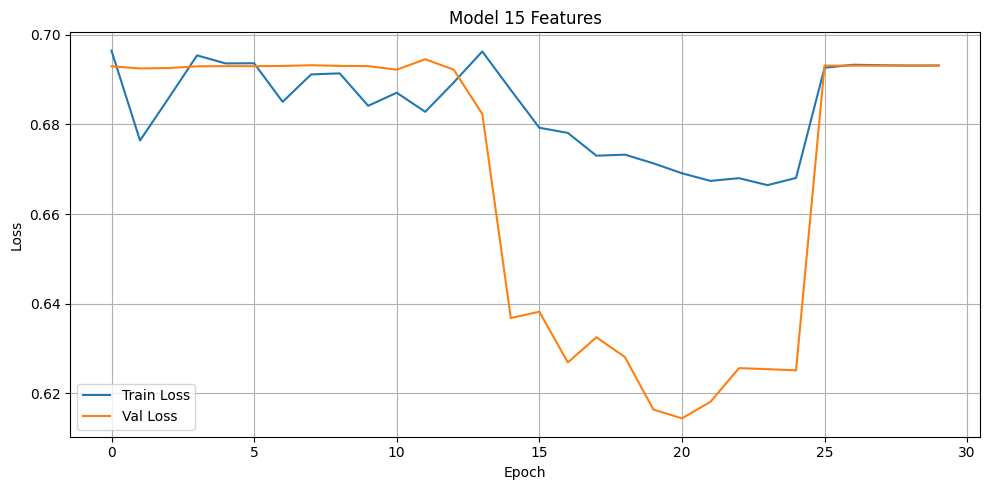

In [ ]:
model=ImageAnalysis(
    input_dim=features.shape[2],
    d_model=64,        # Reduced
    nhead=4,           # Reduced
    num_layers=2,      # Reduced
    dim_feedforward=128, # Reduced
    dropout=0.3, 
    cnn_hidden=128
).to(device)

print("Model Parameters:", sum(p.numel() for p in model.parameters()))

# ==================== OPTIMIZERS & LOSS ====================

# Use smaller learning rate
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)

criterion = nn.BCEWithLogitsLoss()

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# ==================== TRAINING LOOP ====================

num_epochs = 30
best_loss = float('inf')

train_losses = []
val_losses = []

print("\nStarting training...")
for epoch in range(num_epochs):
    # Training phase
    model.train()
    
    train_loss = 0
    
    train_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]')
    
    for target, features, transformed_target in train_bar:
        # Move to device
        features = features.to(device)
        transformed_target = transformed_target.to(device)
        target = target.to(device)
        
        input = torch.cat([features, transformed_target.unsqueeze(1)], dim=1)  # (batch, seq_len, num_features + target_dim)
        input = input.to(device)
        # Train Market Model
        optimizer.zero_grad()
        output, _ = model(input)
        loss = criterion(output, target)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_loss += loss.item()
        
        train_bar.set_postfix({
            'loss': loss.item()
        })
    
    avg_train = train_loss / len(train_loader)
    train_losses.append(avg_train)
    
    model.eval()        
    val_loss = 0

    with torch.no_grad():
        val_bar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]')
        for target, features, transformed_target in val_bar:
            features = features.to(device)
            transformed_target = transformed_target.to(device)
            target = target.to(device)

            input = torch.cat([features, transformed_target.unsqueeze(1)], dim=1)  # (batch, seq_len, num_features + target_dim)
            input = input.to(device)

            output,_ = model(input)
            
            loss = criterion(output, target)
            
            val_loss += loss.item()
            
            val_bar.set_postfix({
                'loss': loss.item()
            })
    
    avg_val = val_loss / len(val_loader)
    val_losses.append(avg_val)
    
    # Update schedulers
    scheduler.step(avg_val)
    
    # Save best models
    if avg_val < best_loss:
        best_loss = avg_val
        torch.save(model.state_dict(), 'best_cnn_model.pth')
        print(f"  ✓ Saved best market model (val_loss: {avg_val:.6f})")
  
    
    # Print epoch summary
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"  Train -: {avg_train:.6f}")
    print(f"  Val   -: {avg_val:.6f}")
    print(f"  LR    -: {optimizer.param_groups[0]['lr']:.6f}")
    print("-" * 60)

print("\nTraining completed!")

# ==================== PLOT TRAINING CURVES ====================

plt.figure(figsize=(10, 5))

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model CNN')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_curves CNN.png')
plt.show()


In [12]:
model.load_state_dict(torch.load('best_cnn_model.pth'))


<All keys matched successfully>

In [13]:
y_pred_list=[]
y_true_list=[]

for target, features, transformed_target in val_loader:
    features = features.to(device)
    target = target.to(device)
    transformed_target = transformed_target.to(device)
    input = torch.cat([features, transformed_target.unsqueeze(1)], dim=1)  # (batch, seq_len, num_features + target_dim)
    input = input.to(device)
    y_pred,_ = model(input)

    y_pred_list.append(y_pred.detach().cpu().numpy())
    y_true_list.append(target.cpu().numpy().reshape(-1))

y_pred = np.concatenate(y_pred_list, axis=0)
y_true = np.concatenate(y_true_list, axis=0)


In [14]:
from sklearn.metrics import roc_auc_score,accuracy_score,precision_score,recall_score,f1_score,classification_report

In [18]:
y_true       = y_true.reshape(-1)
y_pred_label = (y_pred > 0.5).astype(int)
y_pred_label = y_pred_label.reshape(-1)
y_pred_prob  = y_pred.reshape(-1)


In [19]:
print("Accuracy:", accuracy_score(y_true, y_pred_label))
print("Precision:", precision_score(y_true, y_pred_label))
print("Recall:", recall_score(y_true, y_pred_label))
print("F1 Score:", f1_score(y_true, y_pred_label))

# ROC-AUC uses probabilities, NOT labels
print("ROC-AUC:", roc_auc_score(y_true, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_label))

Accuracy: 0.7687418276914136
Precision: 0.8066307501036055
Recall: 0.7069591747784396
F1 Score: 0.7535132205489528
ROC-AUC: 0.7930832441297054

Classification Report:

              precision    recall  f1-score   support

         0.0       0.74      0.83      0.78     13766
         1.0       0.81      0.71      0.75     13766

    accuracy                           0.77     27532
   macro avg       0.77      0.77      0.77     27532
weighted avg       0.77      0.77      0.77     27532



In [ ]:
y_pred_list=[]
features_val_list=[]
y_true_list=[]

for target, features, transformed_target in val_loader:
    features = features.to(device)
    target = target.to(device)
    transformed_target = transformed_target.to(device)
    input = torch.cat([features, transformed_target.unsqueeze(1)], dim=1)  # (batch, seq_len, num_features + target_dim)
    input = input.to(device)
    y_pred,features = model(input)

    y_pred_list.append(y_pred.detach().cpu().numpy())
    features_val_list.append(features.detach().cpu().numpy())
    y_true_list.append(target.cpu().numpy().reshape(-1))

y_pred = np.concatenate(y_pred_list, axis=0)
y_true = np.concatenate(y_true_list, axis=0)
features_val = np.concatenate(features_val_list, axis=0)
y_true_test = y_true.reshape(-1)
features_val_test = features_val.reshape(features_val.shape[0], -1)

In [29]:
features_val_test.shape, y_true_test.shape

((27532, 32), (27532,))

In [ ]:
y_pred_list_train=[]
features_val_list_train=[]
y_true_list_train=[]

for target, features, transformed_target in train_loader:
    features = features.to(device)
    target = target.to(device)
    transformed_target = transformed_target.to(device)
    input = torch.cat([features, transformed_target.unsqueeze(1)], dim=1)  # (batch, seq_len, num_features + target_dim)
    input = input.to(device)
    y_pred,features = model(input)

    y_pred_list_train.append(y_pred.detach().cpu().numpy())
    features_val_list_train.append(features.detach().cpu().numpy())
    y_true_list_train.append(target.cpu().numpy().reshape(-1))

y_pred_train = np.concatenate(y_pred_list_train, axis=0)
y_true_train = np.concatenate(y_true_list_train, axis=0)
features_val_train = np.concatenate(features_val_list_train, axis=0)
y_true_train = y_true_train.reshape(-1)
features_train= features_val_train.reshape(features_val_train.shape[0], -1)

In [31]:
features_train.shape, y_true_train.shape

((64214, 32), (64214,))

In [22]:
from xgboost import XGBClassifier

In [26]:
len(combined_val_dataset)

27532

In [27]:
len(combined_train_dataset)

64214

In [32]:
model_xgb = XGBClassifier()
model_xgb.fit(features_val_train, y_true_train)
y_pred_xgb = model_xgb.predict(features_val_test)
y_pred_xgb_prob = model_xgb.predict_proba(features_val_test)[:, 1]

print("Accuracy:", accuracy_score(y_true_test, y_pred_xgb))
print("Precision:", precision_score(y_true_test, y_pred_xgb))
print("Recall:", recall_score(y_true_test, y_pred_xgb))
print("F1 Score:", f1_score(y_true_test, y_pred_xgb))

# ROC-AUC uses probabilities, NOT labels
print("ROC-AUC:", roc_auc_score(y_true_test, y_pred_xgb_prob))

print("\nClassification Report:\n")
print(classification_report(y_true_test, y_pred_xgb))

Accuracy: 0.7330015981403458
Precision: 0.7646670517369419
Recall: 0.6731802992881011
F1 Score: 0.716013135020282
ROC-AUC: 0.8269902628751216

Classification Report:

              precision    recall  f1-score   support

         0.0       0.71      0.79      0.75     13766
         1.0       0.76      0.67      0.72     13766

    accuracy                           0.73     27532
   macro avg       0.74      0.73      0.73     27532
weighted avg       0.74      0.73      0.73     27532



In [33]:
import optuna

In [34]:
def objective(trial):
    
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
        "use_label_encoder": False,
        "eval_metric": "logloss",
        "random_state": 42,
        "n_jobs": -1
    }

    model = XGBClassifier(**params)

    # Train on given training data
    model.fit(features_val_train, y_true_train)

    # Predict on FULL X (as you requested)
    y_pred = model.predict(features_val_test)

    # Optimize F1 score
    f1 = f1_score(y_true_test, y_pred)

    return f1


# =========================
# RUN OPTUNA
# =========================
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=25, n_jobs=-1)

print("Best F1 Score:", study.best_value)
print("Best Params:", study.best_params)


# =========================
# TRAIN FINAL MODEL
# =========================
best_params = study.best_params

model_xgb = XGBClassifier(
    **best_params,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

model_xgb.fit(features_val_train, y_true_train)

# =========================
# FINAL EVALUATION (your format)
# =========================

y_pred_xgb = model_xgb.predict(features_val_test)

print("XGBoost Accuracy:", accuracy_score(y_true_test, y_pred_xgb))
print("XGBoost Precision:", precision_score(y_true_test, y_pred_xgb))
print("XGBoost Recall:", recall_score(y_true_test, y_pred_xgb))
print("XGBoost F1 Score:", f1_score(y_true_test, y_pred_xgb))
print("XGBoost ROC-AUC:", roc_auc_score(y_true_test, model_xgb.predict_proba(features_val_test)[:, 1]))

print("\nXGBoost Classification Report:\n")
print(classification_report(y_true_test, y_pred_xgb))

[I 2026-04-16 14:00:05,185] A new study created in memory with name: no-name-d259b2ca-71d4-4c70-92c9-ad9049446da9
[14:00:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[14:00:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[14:00:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[14:00:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[14:00:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.
[14:00:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


[14:00:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

[14:00:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder"

Best F1 Score: 0.7187761625694498
Best Params: {'n_estimators': 370, 'max_depth': 8, 'learning_rate': 0.09051720188741376, 'subsample': 0.6514582677895955, 'colsample_bytree': 0.8166337510894816, 'gamma': 0.17909846150688824, 'min_child_weight': 1, 'reg_alpha': 2.607782501472195, 'reg_lambda': 2.0977150136360403}
XGBoost Accuracy: 0.7315850646520412
XGBoost Precision: 0.7547953964194374
XGBoost Recall: 0.6860380647973268
XGBoost F1 Score: 0.7187761625694498
XGBoost ROC-AUC: 0.8272450032336205

XGBoost Classification Report:

              precision    recall  f1-score   support

         0.0       0.71      0.78      0.74     13766
         1.0       0.75      0.69      0.72     13766

    accuracy                           0.73     27532
   macro avg       0.73      0.73      0.73     27532
weighted avg       0.73      0.73      0.73     27532



In [36]:
y_pred_list=[]
features_val_list=[]
y_true_list=[]

for target, features, transformed_target in val_loader:
    features = features.to(device)
    target = target.to(device)
    transformed_target = transformed_target.to(device)
    input = torch.cat([features, transformed_target.unsqueeze(1)], dim=1)  # (batch, seq_len, num_features + target_dim)
    input = input.to(device)
    y_pred,features = model(input)

    y_pred_list.append(y_pred.detach().cpu().numpy())
    temp = torch.cat([transformed_target, features], dim=1)
    features_val_list.append(temp.detach().cpu().numpy())
    y_true_list.append(target.cpu().numpy().reshape(-1))

y_pred = np.concatenate(y_pred_list, axis=0)
y_true = np.concatenate(y_true_list, axis=0)
features_val = np.concatenate(features_val_list, axis=0)
y_true_test = y_true.reshape(-1)
features_val_test = features_val.reshape(features_val.shape[0], -1)

In [37]:
y_pred_list_train=[]
features_val_list_train=[]
y_true_list_train=[]

for target, features, transformed_target in train_loader:
    features = features.to(device)
    target = target.to(device)
    transformed_target = transformed_target.to(device)
    input = torch.cat([features, transformed_target.unsqueeze(1)], dim=1)  # (batch, seq_len, num_features + target_dim)
    input = input.to(device)
    y_pred,features = model(input)
    temp = torch.cat([transformed_target, features], dim=1)
    y_pred_list_train.append(y_pred.detach().cpu().numpy())
    features_val_list_train.append(temp.detach().cpu().numpy())
    y_true_list_train.append(target.cpu().numpy().reshape(-1))

y_pred_train = np.concatenate(y_pred_list_train, axis=0)
y_true_train = np.concatenate(y_true_list_train, axis=0)
features_val_train = np.concatenate(features_val_list_train, axis=0)
y_true_train = y_true_train.reshape(-1)
features_train= features_val_train.reshape(features_val_train.shape[0], -1)

In [38]:
model_xgb_new = XGBClassifier()
model_xgb_new.fit(features_val_train, y_true_train)
y_pred_xgb = model_xgb_new.predict(features_val_test)
y_pred_xgb_prob = model_xgb_new.predict_proba(features_val_test)[:, 1]

print("Accuracy:", accuracy_score(y_true_test, y_pred_xgb))
print("Precision:", precision_score(y_true_test, y_pred_xgb))
print("Recall:", recall_score(y_true_test, y_pred_xgb))
print("F1 Score:", f1_score(y_true_test, y_pred_xgb))

# ROC-AUC uses probabilities, NOT labels
print("ROC-AUC:", roc_auc_score(y_true_test, y_pred_xgb_prob))

print("\nClassification Report:\n")
print(classification_report(y_true_test, y_pred_xgb))

Accuracy: 0.7391399099229987
Precision: 0.7474071847286938
Recall: 0.7224320790353044
F1 Score: 0.7347074468085106
ROC-AUC: 0.8438577932871858

Classification Report:

              precision    recall  f1-score   support

         0.0       0.73      0.76      0.74     13766
         1.0       0.75      0.72      0.73     13766

    accuracy                           0.74     27532
   macro avg       0.74      0.74      0.74     27532
weighted avg       0.74      0.74      0.74     27532



In [40]:
def objective(trial):
    
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
        "eval_metric": "logloss",
        "random_state": 42,
        "n_jobs": -1
    }

    model = XGBClassifier(**params)

    # Train on given training data
    model.fit(features_val_train, y_true_train)

    # Predict on FULL X (as you requested)
    y_pred = model.predict(features_val_test)

    # Optimize F1 score
    f1 = f1_score(y_true_test, y_pred)

    return f1


# =========================
# RUN OPTUNA
# =========================
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50, n_jobs=-1)

print("Best F1 Score:", study.best_value)
print("Best Params:", study.best_params)


# =========================
# TRAIN FINAL MODEL
# =========================
best_params = study.best_params

model_xgb_new = XGBClassifier(
    **best_params,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

model_xgb_new.fit(features_val_train, y_true_train)

# =========================
# FINAL EVALUATION (your format)
# =========================

y_pred_xgb = model_xgb_new.predict(features_val_test)

print("XGBoost Accuracy:", accuracy_score(y_true_test, y_pred_xgb))
print("XGBoost Precision:", precision_score(y_true_test, y_pred_xgb))
print("XGBoost Recall:", recall_score(y_true_test, y_pred_xgb))
print("XGBoost F1 Score:", f1_score(y_true_test, y_pred_xgb))
print("XGBoost ROC-AUC:", roc_auc_score(y_true_test, model_xgb_new.predict_proba(features_val_test)[:, 1]))

print("\nXGBoost Classification Report:\n")
print(classification_report(y_true_test, y_pred_xgb))

[I 2026-04-16 14:06:14,867] A new study created in memory with name: no-name-c10e0bbb-d963-42ac-b6a9-bcfb86f73a6c
[I 2026-04-16 14:06:21,102] Trial 5 finished with value: 0.7325818489593352 and parameters: {'n_estimators': 224, 'max_depth': 9, 'learning_rate': 0.13495004958560602, 'subsample': 0.9902639981374148, 'colsample_bytree': 0.5078769602494757, 'gamma': 2.723624425848747, 'min_child_weight': 7, 'reg_alpha': 3.5708982937263656, 'reg_lambda': 0.020296015684246327}. Best is trial 5 with value: 0.7325818489593352.
[I 2026-04-16 14:06:21,512] Trial 4 finished with value: 0.74209535518076 and parameters: {'n_estimators': 243, 'max_depth': 12, 'learning_rate': 0.2730812173590131, 'subsample': 0.6118900517365882, 'colsample_bytree': 0.632789404064418, 'gamma': 4.662727158151007, 'min_child_weight': 10, 'reg_alpha': 1.3716177158805603, 'reg_lambda': 2.950073478278873}. Best is trial 4 with value: 0.74209535518076.
[I 2026-04-16 14:06:23,158] Trial 6 finished with value: 0.73328276577907

Best F1 Score: 0.7646070419308028
Best Params: {'n_estimators': 337, 'max_depth': 10, 'learning_rate': 0.10688764577817207, 'subsample': 0.7269736586402804, 'colsample_bytree': 0.921351603836381, 'gamma': 0.7690378444096395, 'min_child_weight': 1, 'reg_alpha': 4.077060755138467, 'reg_lambda': 4.466000832428299}
XGBoost Accuracy: 0.7761150661048961
XGBoost Precision: 0.8060386473429951
XGBoost Recall: 0.7272265000726428
XGBoost F1 Score: 0.7646070419308028
XGBoost ROC-AUC: 0.8695277339396583

XGBoost Classification Report:

              precision    recall  f1-score   support

         0.0       0.75      0.83      0.79     13766
         1.0       0.81      0.73      0.76     13766

    accuracy                           0.78     27532
   macro avg       0.78      0.78      0.78     27532
weighted avg       0.78      0.78      0.78     27532

